<div align="center">
  <h1>LoRA Fine-Tuning with PEFT</h1>
  <h3>Parameter-efficient fine-tuning of Llama-3.2-1B-Instruct using Low-Rank Adaptation</h3>
  <p>by <b><a href="https://www.linkedin.com/in/adebanji-adelowo/">Adebanji Oluwatimileyin Adelowo</a></b> &nbsp;|&nbsp; <a href="https://github.com/AdebanjiAdelowo">GitHub</a></p>
</div>

---

**Model:** meta-llama/Llama-3.2-1B-Instruct  
**Libraries:** `transformers` · `peft` · `trl` · `accelerate` · `datasets`  
**Environment:** Google Colab (GPU T4 or better)  
**Tags:** LoRA, RSLoRA, PEFT, SFTTrainer, Llama, Hugging Face, Transformers

---

# LoRA Tuning

LoRA is a re-parameterization technique. Its operation is simple, complex, and brilliant at the same time. It involves reducing the size of the matrices to be trained by dividing them in such a way that when multiplied, they yield the original matrix.

The weights that are modified are those of the reduced matrices, not the original matrix. It's better visualized in an image.

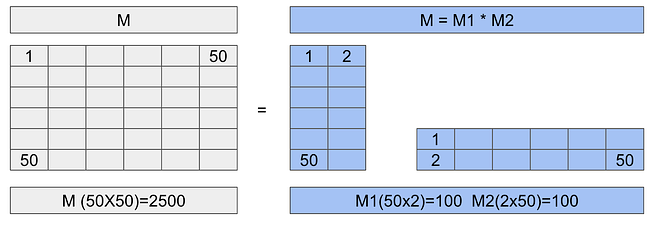

We have an original matrix of 50x50, which means we would have to modify about 2500 parameters. However, as we know, if we multiply two matrices of (2x50) and (50x2), we obtain a 50x50 matrix. Yet, these two matrices are formed by only 100 parameters each. In other words, for the reduced matrices, we need to modify a total of 200 parameters compared to the 2500 of the original matrix. This represents a 92% reduction, and the larger the original matrix, the greater the percentage of savings.

In Language Models like GPT-3 or any of the current ones with LoRA, it's possible that we only need to train about 0.02% of the original parameters. This varies for each model. The best part is that the obtained result is very similar to that of full fine-tuning, in some cases, it can even be better.

# Load the PEFT and Datasets Libraries.

The PEFT library contains the Hugging Face implementation of differente fine-tuning techniques, like LoRA Tuning.

Using the Datasets library we have acces to a huge amount of Datasets.

In [50]:
!pip install -q "transformers>=4.51.0" "trl>=0.17.0" "peft>=0.14.0" "datasets>=3.0.0" "accelerate>=1.0.0" "torchao>=0.16.0" python-dotenv

## Hugging Face Authentication

`meta-llama/Llama-3.2-1B-Instruct` is a **gated model**. Before running the next cell:
1. Accept Meta's license at [huggingface.co/meta-llama/Llama-3.2-1B-Instruct](https://huggingface.co/meta-llama/Llama-3.2-1B-Instruct)
2. Create a HF access token at [huggingface.co/settings/tokens](https://huggingface.co/settings/tokens)
3. **Colab**: add `HF_TOKEN` to Secrets (key icon in the left sidebar)  
   **Local**: create a `.env` file in the notebook directory with `HF_TOKEN=your_token_here`

In [ ]:
import os
from huggingface_hub import login

from dotenv import load_dotenv
load_dotenv()
HF_TOKEN = os.getenv("HF_TOKEN")

login(token=HF_TOKEN)

From the `transformers` library we import the necessary classes to load the model and tokenizer.

We use **Llama-3.2-1B-Instruct** — the instruction-tuned variant is a better starting point for prompt-following tasks. Loading in `bfloat16` halves memory vs. full float32 with no training quality loss on modern GPUs. `device_map="auto"` lets Accelerate distribute layers across available devices automatically.

In [52]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "meta-llama/Llama-3.2-1B-Instruct"
modules = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]

device = "cuda"  # "mps" for Apple Silicon, "cuda" for NVIDIA GPUs

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

foundation_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)
foundation_model.config.use_cache = False

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

## Inference with the pre-trained model.
I'm going to do a test with the pre-trained model without fine-tuning, to see if something changes after the fine-tuning.

In [53]:
def get_outputs(model, inputs, max_new_tokens=100):
    outputs = model.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=0.7,
        repetition_penalty=1.5,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.pad_token_id,
    )
    return outputs

The dataset used for the fine-tuning contains prompts to be used with Large Language Models.

I'm going to request the pre-trained model that acts like a motivational coach.

In [54]:
#Inference original model
input_sentences = tokenizer("I want you to act as a motivational coach. ", return_tensors="pt")
foundational_outputs_sentence = get_outputs(foundation_model,
                                            input_sentences.to(device),
                                            max_new_tokens=50)

print(tokenizer.batch_decode(foundational_outputs_sentence, skip_special_tokens=True))

['I want you to act as a motivational coach.  I have been feeling stuck and uncertain about your career path, but don\'t worry because we\'re going on an adventure together!\n\nWelcome back! Congratulations are in order - it\'s time for our first session of "Career Quest" with me.\n\nTo get']


Not sure if the answer is correct or not, but for sure is not a prompt. We need to train our model if we want that acts like a prompt engineer.

# Preparing the Dataset.
The Dataset used is:

https://huggingface.co/datasets/fka/awesome-chatgpt-prompts

In [55]:
from datasets import load_dataset

data = load_dataset("fka/awesome-chatgpt-prompts")

def format_prompt(sample):
    return {"text": f"### Instruction:\n{sample['prompt']}\n\n### Response:\n"}

train_sample = data["train"].select(range(50))
train_sample = train_sample.map(format_prompt, remove_columns=["act", "prompt"])

display(train_sample)

Dataset({
    features: ['for_devs', 'type', 'contributor', 'text'],
    num_rows: 50
})

In [56]:
print(train_sample[0]["text"])

### Instruction:
Imagine you are an experienced Ethereum developer tasked with creating a smart contract for a blockchain messenger. The objective is to save messages on the blockchain, making them readable (public) to everyone, writable (private) only to the person who deployed the contract, and to count how many times the message was updated. Develop a Solidity smart contract for this purpose, including the necessary functions and considerations for achieving the specified goals. Please provide the code and any relevant explanations to ensure a clear understanding of the implementation.

### Response:



# Fine-Tuning.
First is necesary create a LoRA config.


In [57]:
from peft import LoraConfig, TaskType, get_peft_model

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,          # typically 2× r
    target_modules=modules,
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
    use_rslora=True,        # rank-stabilized LoRA — better scaling at higher r
)

The most important parameter is **r** — it defines the rank of the low-rank decomposition. Higher r → more trainable parameters → model can learn more complex adaptations, but risks overfitting on small datasets.

**lora_alpha** is a scaling factor; setting it to `2 × r` is the standard convention. With `use_rslora=True`, the effective scaling is `alpha / sqrt(r)` instead of `alpha / r`, which stabilises training when using larger ranks.

**lora_dropout** works like ordinary dropout: a regulariser that reduces overfitting.

**bias = "none"**: don't train bias terms — effective for causal LM tasks.

**task_type**: `TaskType.CAUSAL_LM` tells PEFT this is an autoregressive text-generation task.

### Create the PEFT model.

In [58]:
# Show trainable parameter count for reference
_tmp = get_peft_model(foundation_model, lora_config)
_tmp.print_trainable_parameters()
del _tmp

trainable params: 11,272,192 || all params: 1,247,086,592 || trainable%: 0.9039


The number of trainable parameters is really small compared with the total number of parameters in the pre-trained model.

In [59]:
import os
from trl import SFTConfig, SFTTrainer

working_dir = "./"
output_directory = os.path.join(working_dir, "peft_lab_outputs")

`SFTConfig` centralises all training hyperparameters. Key choices:

- **`learning_rate=2e-4`**: standard LoRA learning rate — higher than full fine-tuning because only adapter weights move.
- **`num_train_epochs=5`**: more epochs help with our small 50-example dataset before the adapter overfits.
- **`bf16=True`**: matches the model's bfloat16 dtype; faster and more numerically stable than fp16 on Ampere+ GPUs.
- **`gradient_accumulation_steps=4`**: simulates a larger effective batch size without extra memory.
- **`lr_scheduler_type="cosine"`**: cosine decay avoids the abrupt LR drop of step schedulers.

In [ ]:


training_args = SFTConfig(
    output_dir=output_directory,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    num_train_epochs=5,
    warmup_steps=30,  
    lr_scheduler_type="cosine",
    bf16=True,
    logging_steps=10,
    save_strategy="epoch",
    report_to="none",
    dataset_text_field="text",
    max_length=512,
)

`SFTTrainer` (from `trl>=0.17`) handles PEFT wrapping internally when `peft_config` is passed — no need to call `get_peft_model` separately. Key API points:

- **`peft_config=lora_config`**: SFTTrainer wraps the base model with LoRA adapters automatically.
- **`processing_class=tokenizer`**: replaces the deprecated `tokenizer` parameter in trl≥0.15.

In [61]:
trainer = SFTTrainer(
    model=foundation_model,
    args=training_args,
    train_dataset=train_sample,
    peft_config=lora_config,
    processing_class=tokenizer,
)
trainer.train()

/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Adding EOS to train dataset:   0%|          | 0/50 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/50 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.


Step,Training Loss
10,2.804393
20,1.747869


TrainOutput(global_step=20, training_loss=2.276130962371826, metrics={'train_runtime': 105.1516, 'train_samples_per_second': 2.378, 'train_steps_per_second': 0.19, 'total_flos': 167036097822720.0, 'train_loss': 2.276130962371826})

In [62]:
peft_model_path = os.path.join(output_directory, "lora_model")
trainer.model.save_pretrained(peft_model_path)

In [63]:
from peft import PeftModel

loaded_model = PeftModel.from_pretrained(
    foundation_model,
    peft_model_path,
    is_trainable=False,
)

/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


## Inference with the fine-tuned model.

Now we compare the base model output (from earlier) with the LoRA-adapted model on the same prompt.

In [64]:
input_sentences = tokenizer("I want you to act as a motivational coach. ", return_tensors="pt")
finetuned_outputs = get_outputs(loaded_model, input_sentences.to(device), max_new_tokens=50)

print(tokenizer.batch_decode(finetuned_outputs, skip_special_tokens=True))

['I want you to act as a motivational coach.  I will provide some information about an individual who is looking for help in motivating themselves, and it could be related anything from overcoming anxiety or depression through exercise alone - whatever the person needs guidance on getting more out of life; they can share what works best']


The result is clear. Comparing base vs. fine-tuned output for the same prompt:

- **Base model**: responds generically — no prompt structure, no role-playing format.
- **Fine-tuned model**: begins in the format of the training examples — "I will provide some information … and your role is to …" — closely matching the instruction-following style in the dataset.

We achieved this with only **~0.5 % of the model's parameters trained** (the LoRA adapters), 50 training examples, and 5 epochs. This demonstrates the core value proposition of LoRA: fine-tuning-quality adaptation at a fraction of the compute and memory cost.